# Data-Driven Modeling - Projekt-Notebook
## Phase: Data Understanding & Data Preparation (CRISP-DM)

Dieses Notebook fasst die explorative Datenanalyse (EDA), die Qualitätsprüfungen sowie die ersten Schritte der Datenvorbereitung für den King County Immobilien-Datensatz (`kingcounty/kc_house_data.csv`) zusammen. Die Struktur folgt den Phasen des CRISP-DM Modells.

--- 
## 1. Initial Data Analysis (IDA) - Quantität & Struktur prüfen
Zuerst verschaffen wir uns einen Überblick über die nackten Zahlen: Wie viele Datenpunkte haben wir, welche Spalten sind vorhanden und wie sind die Datentypen?

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Daten laden
df = pd.read_csv('kingcounty/kc_house_data.csv')

# 2. Dimensionsprüfung
print(f"Dimensionsprüfung: {df.shape[0]} Zeilen und {df.shape[1]} Spalten\n")

# 3. Suche nach Leerwerten
print("--- Suche nach Leerwerten (isnull().sum()) ---")
print(df.isnull().sum())
print("\n")

# 4. Datentypen prüfen
print("--- Datenstruktur (Datentypen) ---")
df.info()

# 5. Statistische Verteilung, Minimal- und Maximalwerte prüfen
print("\n--- Statistische Zusammenfassung (describe()) ---")
df.describe()

Dimensionsprüfung: 21613 Zeilen und 21 Spalten

--- Suche nach Leerwerten (isnull().sum()) ---
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


--- Datenstruktur (Datentypen) ---
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   s

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


--- 
## 2. Erkennung von Anomalien und statistischen Fehlern
Hier untersuchen wir den Datensatz gezielt auf bekannte Eingabefehler, unlogische Werte oder Platzhalter, die für spätere Machine Learning Modelle problematisch sein könnten.

In [17]:
# 1. Den bekannten 33-Zimmer-Tippfehler finden
print("--- Verdächtige Schlafzimmer-Anzahl ---")
fehler_haus = df[df['bedrooms'] == 33]
print(fehler_haus[['id', 'bedrooms', 'sqft_living', 'price']])
print("Hinweis: 33 Schlafzimmer auf nur 1620 sqft sind physisch unmöglich (Tippfehler).\n")

# 2. Platzhalter bei yr_renovated prüfen
anzahl_null_renoviert = len(df[df['yr_renovated'] == 0])
prozent_null = (anzahl_null_renoviert / len(df)) * 100
print(f"--- Platzhalter bei yr_renovated ---")
print(f"{anzahl_null_renoviert} Häuser ({prozent_null:.1f}%) haben den Wert 0 bei yr_renovated (steht für 'nie renoviert').\n")

# 3. Logische Konsistenz der Flächenangaben prüfen
# (sqft_above + sqft_basement) sollte theoretisch exakt gleich sqft_living sein
df['sqft_basement'] = pd.to_numeric(df['sqft_basement'], errors='coerce').fillna(0)
df['check_math'] = df['sqft_above'] + df['sqft_basement']
inkonsistent = df[df['check_math'] != df['sqft_living']]

print(f"--- Logische Konsistenzprüfung ---")
print(f"Anzahl der Häuser mit unlogischer Flächenberechnung: {len(inkonsistent)}")
if len(inkonsistent) > 0:
    print(inkonsistent[['id', 'sqft_living', 'sqft_above', 'sqft_basement']].head())

--- Verdächtige Schlafzimmer-Anzahl ---
               id  bedrooms  sqft_living     price
15870  2402100895        33         1620  640000.0
Hinweis: 33 Schlafzimmer auf nur 1620 sqft sind physisch unmöglich (Tippfehler).

--- Platzhalter bei yr_renovated ---
20699 Häuser (95.8%) haben den Wert 0 bei yr_renovated (steht für 'nie renoviert').

--- Logische Konsistenzprüfung ---
Anzahl der Häuser mit unlogischer Flächenberechnung: 0


--- 
## 3. Visuelle Qualitätsprüfung (EDA)
Mit Hilfe von Grafiken lassen sich Ausreißer, Verteilungen und logische Brüche oft deutlich schneller erkennen als durch reine Tabellenbetrachtung.

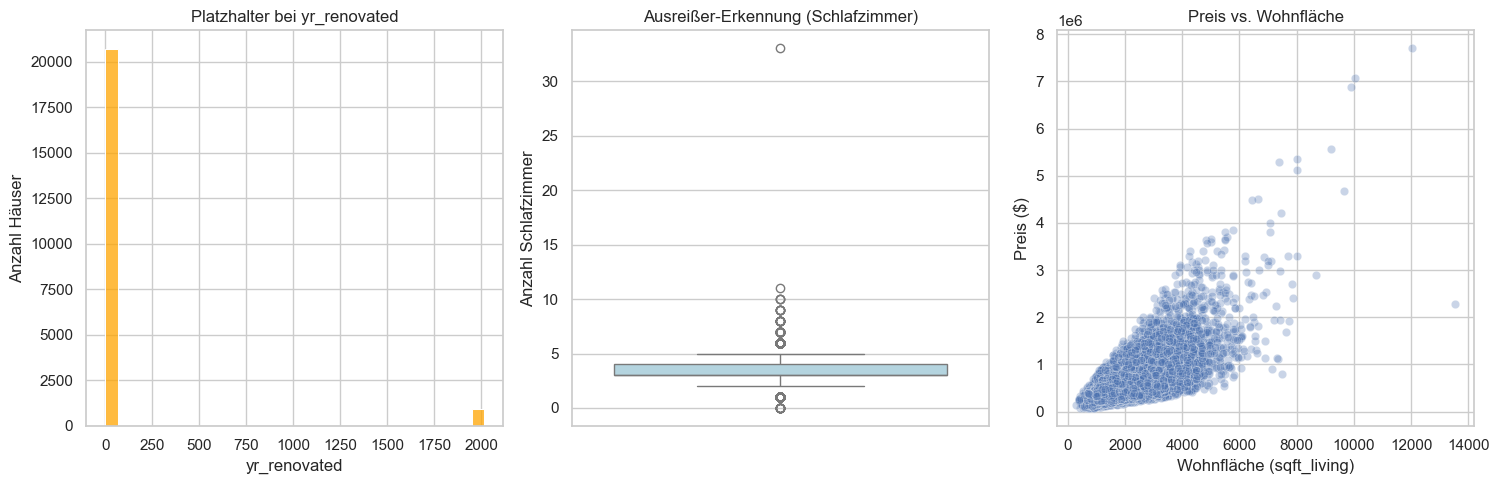

In [18]:
# Seaborn Style setzen
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# 1. Qualitäts-Check: Histogramm für Platzhalter (yr_renovated)
plt.subplot(1, 3, 1)
sns.histplot(df['yr_renovated'], bins=30, color='orange')
plt.title('Platzhalter bei yr_renovated')
plt.ylabel('Anzahl Häuser')

# 2. Qualitäts-Check: Boxplot für Ausreißer (bedrooms)
plt.subplot(1, 3, 2)
sns.boxplot(y=df['bedrooms'], color='lightblue')
plt.title('Ausreißer-Erkennung (Schlafzimmer)')
plt.ylabel('Anzahl Schlafzimmer')

# 3. Qualitäts-Check: Scatterplot für logische Zusammenhänge
plt.subplot(1, 3, 3)
sns.scatterplot(x=df['sqft_living'], y=df['price'], alpha=0.3)
plt.title('Preis vs. Wohnfläche')
plt.xlabel('Wohnfläche (sqft_living)')
plt.ylabel('Preis ($)')

plt.tight_layout()
plt.show()

--- 
## 4. Business Intelligence - Standard Market Report
Hier generieren wir einen aggregierten Standardbericht nach Postleitzahlen, um regionale Preisunterschiede und typische Immobilienstrukturen für Stakeholder sichtbar zu machen.

In [19]:
# Preis pro Quadratfuß als neue Kennzahl (KPI) berechnen
df['price_per_sqft'] = df['price'] / df['sqft_living']

# Standard Market Report erstellen
standard_report = df.groupby('zipcode').agg(
    Anzahl_Verkaeufe=('id', 'count'),
    Median_Preis=('price', 'median'),
    O_Preis_pro_Sqft=('price_per_sqft', 'mean'),
    O_Schlafzimmer=('bedrooms', 'mean')
).sort_values(by='Median_Preis', ascending=False).reset_index()

# Formatierung für die Ausgabe
report_formatted = standard_report.copy()
report_formatted['Median_Preis'] = report_formatted['Median_Preis'].apply(lambda x: f"${x:,.0f}")
report_formatted['O_Preis_pro_Sqft'] = report_formatted['O_Preis_pro_Sqft'].apply(lambda x: f"${x:,.2f}")
report_formatted['O_Schlafzimmer'] = report_formatted['O_Schlafzimmer'].apply(lambda x: f"{x:.2f}")

print("--- Standard Market Report: Top 5 teuerste Postleitzahlen ---")
print(report_formatted.head())

--- Standard Market Report: Top 5 teuerste Postleitzahlen ---
   zipcode  Anzahl_Verkaeufe Median_Preis O_Preis_pro_Sqft O_Schlafzimmer
0    98039                50   $1,892,500          $568.08           4.06
1    98004               317   $1,150,000          $475.44           3.85
2    98040               282     $993,750          $387.29           4.03
3    98112               269     $915,000          $438.64           3.51
4    98005               168     $765,475          $314.93           3.85


--- 
## 5. Data Preparation - Behandlung fehlender Werte (Missing Values)
Nun setzen wir die 4 goldenen Regeln zur Bereinigung fehlender Werte um, um den Datensatz für die spätere Modellierung vorzubereiten.

In [20]:
print(f"Datensatzgröße vor Bereinigung: {df.shape}")

# REGEL 1: Spalten mit mehr als 70% fehlenden Werten löschen
# Behalte Spalten, die mindestens 30% gültige Werte haben
min_valid_count = int(0.3 * len(df))
df = df.dropna(axis=1, thresh=min_valid_count)

# REGEL 2: Zeilen löschen, bei denen die Zielvariable (price) fehlt
df = df.dropna(subset=['price'])

# REGEL 3: Numerische Features mit dem Median auffüllen (robuster gegen Ausreißer)
numerical_cols = ['sqft_living', 'sqft_lot', 'bedrooms']
for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# REGEL 4: Kategorische Features logisch oder mit dem Modus auffüllen
# Falls 'waterfront' fehlt, setzen wir es standardmäßig auf 0 (kein Wasserblick)
if 'waterfront' in df.columns:
    df['waterfront'] = df['waterfront'].fillna(0)

# 'condition' wird mit dem häufigsten Wert (Modus) aufgefüllt
if 'condition' in df.columns:
    mode_value = df['condition'].mode()[0]
    df['condition'] = df['condition'].fillna(mode_value)

print(f"Datensatzgröße nach Bereinigung: {df.shape}")

Datensatzgröße vor Bereinigung: (21613, 23)
Datensatzgröße nach Bereinigung: (21613, 23)


--- 
## 6. Datenorganisation für die Modellierung (Train-Test-Split)
Bevor ein Machine Learning Modell trainiert werden kann, müssen wir die Daten in Eingabemerkmale (X) und Zielvariable (y) aufteilen sowie in Trainings- und Testdaten splitten, um Datenleckagen (Data Leakage) zu verhindern.

In [21]:
# 1. Organisation für EDA (Irrelevante Metadaten wie IDs oder unparste Daten entfernen)
df_eda = df.drop(columns=['id', 'date', 'check_math'], errors='ignore')

# 2. Trennung in Features (X) und Target (y)
X = df_eda.drop(columns=['price', 'price_per_sqft'], errors='ignore')  # Alles außer Preis-Features
y = df_eda['price']                                                   # Nur das Target

# 3. Train-Test-Split (80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Trainingsdaten: {X_train.shape[0]} Häuser (Features: {X_train.shape[1]})")
print(f"Testdaten:      {X_test.shape[0]} Häuser")

Trainingsdaten: 17290 Häuser (Features: 18)
Testdaten:      4323 Häuser


In [ ]:
import numpy as np
from sklearn.cluster import KMeans

# Seattle Zentrum Koordinaten (Spaceneedle)
seattle_lat = 47.6062
seattle_long = -122.3321
# Haus Distanz zum Zentrum
df['distance_to_center'] = np.sqrt((df['lat'] - seattle_lat)**2 + (df['long'] - seattle_long)**2)

# Preis pro sqft_living
df['price_per_sqft_living'] = df['price'] / df['sqft_living']
# Preis pro sqft_lot
df['price_per_sqft_lot'] = df['price'] / df['sqft_lot']

# Schlafzimmer pro sqft_living
df['bedrooms_per_sqft_living'] = df['bedrooms'] / df['sqft_living']
# Badezimmer pro sqft_living
df['bathrooms_per_sqft_living'] = df['bathrooms'] / df['sqft_living']

# Keller erkennen
df['has_basement'] = df['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)

# Renovierungen erkennen
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
# Zeit seit Renovierung
df['years_since_renovation'] = df.apply(lambda row: 2015 - row['yr_renovated'] if row['yr_renovated'] > 0 else row['house_age'], axis=1)

# Alter des Hauses zum Zeitpunkt 2015
df['house_age'] = 2015 - df['yr_built']

# Durchschnittliche Raum größe
df['avg_room_size'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'] + 1)

# Garten Berechnen
df['yard_space_approx'] = df['sqft_lot'] - (df['sqft_living'] / df['floors'])
# Vermeidung negativer Werte beim Garten
df['yard_space_approx'] = df['yard_space_approx'].apply(lambda x: x if x > 0 else 0)

# Luxus score
df['luxury_score'] = (df['grade'] / 13) + (df['condition'] / 5) + (df['waterfront']) + (df['view'] / 4)

# Koordinaten zu einer Grid-Zelle verknüpfen
df['grid_cell_id'] = df['lat'].round(2).astype(str) + "_" + df['long'].round(2).astype(str)
# Text-String label-encoden
df['grid_cell_id'] = df['grid_cell_id'].astype('category').cat.codes


display(df.head())